<a href="https://colab.research.google.com/github/Kaniz-Ankan/lung-image-classification-cnn/blob/main/lung_image_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os
import cv2
from tqdm import tqdm
import numpy as np
from sklearn.preprocessing import LabelEncoder


from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# create labels
classes = []
filename = "//content/drive/MyDrive/MACHINE LEARNING/Dataset/"
lfw_dir = os.path.join(filename, 'lungDsImg')
for sub_folder in sorted(os.listdir(lfw_dir)):
    if os.path.isdir(os.path.join(lfw_dir, sub_folder)):
        classes.append(sub_folder)
print("Classes:", classes)


Classes: ['L', 'N', 'V']


In [ ]:
# load images (auto-detect color vs grayscale) and preprocess
IMG_H, IMG_W = 28, 28

filepaths = []
labels = []
for cls in classes:
    path_train = os.path.join(lfw_dir, cls)
    for fn in os.listdir(path_train):
        if fn.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tiff")):
            filepaths.append(os.path.join(path_train, fn))
            labels.append(cls)

# detect whether any image is color (3 channels)
required_channels = 1
for fp in tqdm(filepaths, desc="Detecting image channels"):
    im = cv2.imread(fp, cv2.IMREAD_UNCHANGED)
    if im is None:
        continue
    if len(im.shape) == 3 and im.shape[2] == 3:
        required_channels = 3
        break
print("Detected required channels:", required_channels)

X = []
y = []
bad = 0
for fp, lbl in tqdm(zip(filepaths, labels), total=len(filepaths), desc="Loading & preprocessing"):
    img = cv2.imread(fp, cv2.IMREAD_UNCHANGED)
    if img is None:
        bad += 1
        continue
    # if color, convert BGR->RGB
    if len(img.shape) == 3 and img.shape[2] == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # if grayscale but we need RGB, convert
    if len(img.shape) == 2 and required_channels == 3:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    # if color but we want grayscale, convert
    if len(img.shape) == 3 and img.shape[2] == 3 and required_channels == 1:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    # resize
    img = cv2.resize(img, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
    # ensure channel axis
    if required_channels == 1:
        if len(img.shape) == 2:
            img = np.expand_dims(img, axis=-1)  # (H,W,1)
    else:
        # ensure shape (H,W,3)
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    # normalize to [0,1] float32
    img = img.astype(np.float32) / 255.0
    X.append(img)
    y.append(lbl)

print(f"Loaded {len(X)} images, skipped {bad} unreadable files.")
X = np.array(X)
y = np.array(y)
print("X shape:", X.shape)
print("y shape:", y.shape)

# encode labels
lb = LabelEncoder()
y_encoded = lb.fit_transform(y)
print("Encoded classes:", list(lb.classes_))


Detecting image channels:   0%|          | 0/211 [00:00<?, ?it/s]


Detected required channels: 3


Loading & preprocessing: 100%|██████████| 211/211 [02:15<00:00,  1.56it/s]

Loaded 211 images, skipped 0 unreadable files.
X shape: (211, 28, 28, 3)
y shape: (211,)
Encoded classes: [np.str_('L'), np.str_('N'), np.str_('V')]


Using input_shape = (28, 28, 3)  num_classes = 3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,051 (476.76 KB)

 Trainable params: 122,051 (476.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.3600 - loss: 1.1266 - val_accuracy: 0.4186 - val_loss: 1.0181
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4554 - loss: 1.0075 - val_accuracy: 0.5349 - val_loss: 0.9390
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5756 - loss: 0.9359 - val_accuracy: 0.6977 - val_loss: 0.8232
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6756 - loss: 0.8146 - val_accuracy: 0.7442 - val_loss: 0.6949
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8012 - loss: 0.7021 - val_accuracy: 0.7674 - val_loss: 0.5834
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8474 - loss: 0.5843 - val_accuracy: 0.7907 - val_loss: 0.5269
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8046 - loss: 0.5472 - val_accuracy: 0.7674 - val_loss: 0.5010
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8490 - loss: 0.4512 - val_accuracy: 0.7674 - val_loss: 0.5131


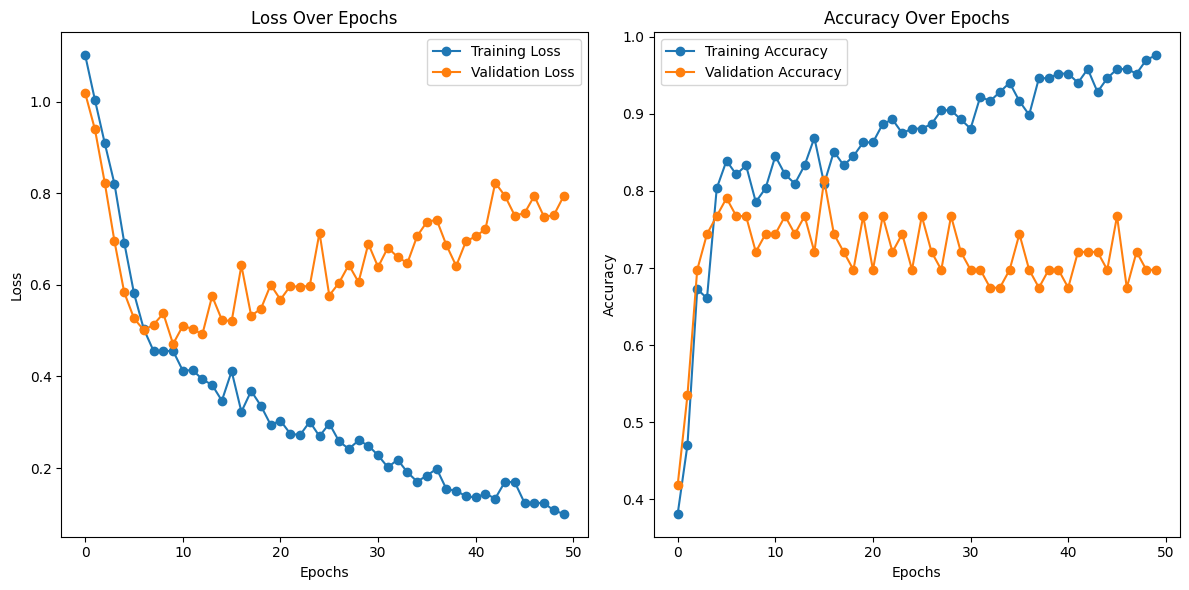

Final Training Accuracy: 0.9762
Final Validation Accuracy: 0.6977


In [ ]:
# split (use stratify to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# determine channels and input_shape
channels = X_train.shape[-1] if X_train.ndim == 4 else 1
input_shape = (IMG_H, IMG_W, channels)
num_classes = len(lb.classes_)
print("Using input_shape =", input_shape, " num_classes =", num_classes)

# build CNN (adapts to channels and num_classes)
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

# train
EPOCHS = 50
history = model.fit(X_train, y_train, epochs=EPOCHS, validation_data=(X_test, y_test))

# plots
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss Over Epochs'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Accuracy Over Epochs'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

plt.tight_layout(); plt.show()

# final accuracy
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f'Final Training Accuracy: {final_train_acc:.4f}')
print(f'Final Validation Accuracy: {final_val_acc:.4f}')
